# Phase 6 — Feature Importance & Error Analysis

Notebooks 06 and 08 establish *that* the deployed Random Forest (`total_points_direct`) gets R²≈0.32, and that this is stable across season boundaries, not a lucky split. Neither asks *why* R² isn't higher, or *which* rows the error concentrates in. This notebook does — a diagnostic pass before deciding whether to invest in Phase 7's advanced features on top of the current model, or fix something in the model first.

Uses `src/models/error_analysis.py` against the exact model artifact `predict_live.py` serves live predictions from, scored on the same held-out 2025-26 season.

In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import pandas as pd

from src.models.error_analysis import (
    feature_importance, load_deployed_model, residuals_by_bucket,
    residuals_by_position, score_test_set, worst_misses,
)

pd.set_option("display.width", 160)
model, feature_cols, model_id, model_type, artifact_path = load_deployed_model()
print(f"model_id={model_id} ({model_type})")
test_df = score_test_set(model, feature_cols)
print(f"Held-out 2025-26: n={len(test_df)}")

model_id=31 (random_forest)


Held-out 2025-26: n=28648


## Feature importance

What does the model actually key off of?

,importance
minutes_roll3,0.6156
ict_index_roll3,0.1022
ict_index_roll5,0.0780
price,0.0459
season_points_per90_avg,0.0216
season_minutes_avg,0.0194
minutes_roll5,0.0130
xgc_per90_roll5,0.0092
xgc_per90_roll3,0.0079
bps_roll3,0.0076


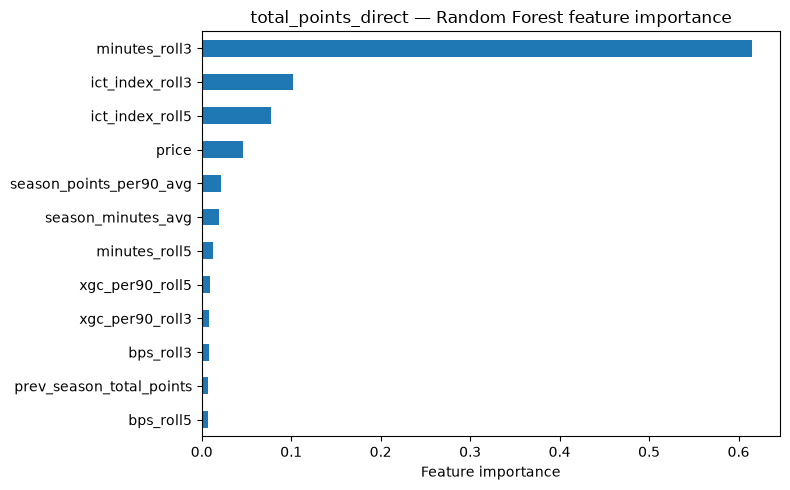

In [2]:
imp = feature_importance(model, feature_cols)
display(imp.head(12).to_frame("importance").round(4))

fig, ax = plt.subplots(figsize=(8, 5))
imp.head(12).sort_values().plot.barh(ax=ax)
ax.set_xlabel("Feature importance")
ax.set_title("total_points_direct — Random Forest feature importance")
plt.tight_layout()
plt.show()

**`minutes_roll3` alone accounts for ~62% of total importance**, with `ict_index_roll3` + `ict_index_roll5` adding another ~18% — together, three features explain ~80% of the model's decisions. That tracks with Phase 4's own finding that ~61% of rows are unused/fringe players with 0 minutes: correctly predicting *whether a player plays at all* explains most of the variance almost by construction. Everything past "will they play, and are they involved in play" — price, season averages, prior-season carryover, bps, xG-conceded, assists — contributes only marginally (each under 5%). That's a meaningful gap: the genuinely hard question, "how well will they play, given that they play," is only weakly captured today.

## Residuals by position

Is error spread evenly across GKP/DEF/MID/FWD, or concentrated somewhere?

In [3]:
display(residuals_by_position(test_df).round(3))

,n,mean_actual,mean_pred,bias,mae
position,,,,,
DEF,9373.0,1.247,1.093,-0.154,1.126
FWD,3162.0,1.302,1.348,0.045,1.113
GK,3302.0,0.750,0.743,-0.006,0.587
MID,12811.0,1.183,1.202,0.019,0.977


GK is by far the easiest to predict (MAE=0.59) — low ceiling, low variance, mostly appearance points. DEF has the largest negative bias (-0.15): the model slightly underrates defenders on average, plausible given clean-sheet swings are lumpy and hard to see coming from rolling stats alone. MID and FWD are close to unbiased on average — but "unbiased on average" can still hide a systematic pattern within the group, which the next section finds.

## The real finding: the model doesn't see hauls coming

Bucket actual outcomes and compare the model's *average prediction* within each band. If predictions tracked reality, `mean_pred` would rise in step with `mean_actual` across the row.

,n,mean_actual,mean_pred,mae
bucket,,,,
blank (0),18071.0,0.000,0.400,0.400
1-2,6399.0,1.376,2.176,1.068
3-5,2100.0,3.754,2.581,1.402
6-10,1637.0,7.368,2.753,4.615
11+ (haul),366.0,13.150,3.079,10.071


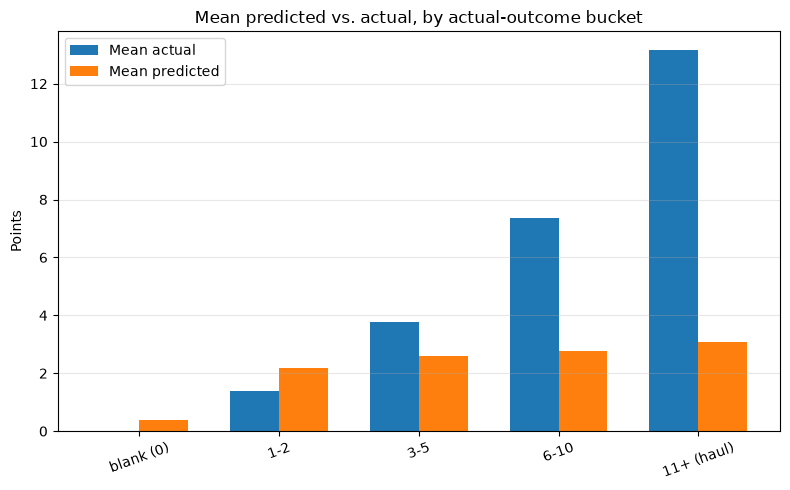

In [4]:
bucket_summary = residuals_by_bucket(test_df)
display(bucket_summary.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(bucket_summary))
width = 0.35
ax.bar([i - width/2 for i in x], bucket_summary["mean_actual"], width, label="Mean actual")
ax.bar([i + width/2 for i in x], bucket_summary["mean_pred"], width, label="Mean predicted")
ax.set_xticks(list(x))
ax.set_xticklabels(bucket_summary.index, rotation=20)
ax.set_ylabel("Points")
ax.set_title("Mean predicted vs. actual, by actual-outcome bucket")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

This is the headline finding. The model's average prediction barely moves past ~3 points no matter how big the actual result gets:

| Actual outcome | Mean actual | Mean predicted |
|---|---|---|
| blank (0 pts) | 0.0 | 0.40 |
| 1-2 pts | 1.38 | 2.18 |
| 3-5 pts | 3.75 | 2.58 |
| 6-10 pts | 7.37 | **2.75** |
| 11+ pts (a haul) | 13.15 | **3.08** |

For an actual haul (11+ points — a goal/assist/clean-sheet/bonus explosion), the model predicts less than a quarter of what actually happened, on average. This is textbook regression-to-the-mean for an MSE-trained model on a right-skewed target: when the model can't confidently identify *which specific player, which specific gameweek* will explode, hedging toward a low, safe prediction minimizes squared error far better than guessing big and being wrong. It's the mathematically correct thing for the model to do under its training objective — and exactly the thing that matters least for MAE/R² but *most* for captaincy, where doubling a haul is where a gameweek is actually won.

This means the model's captain recommendations are systematically biased toward safe, consistent floor players over high-ceiling differentials — worth knowing given the decision-engine backtest (notebook 07) already showed the transfer plan, not weekly captain/lineup judgment, is the bigger value driver. This may be part of why: the model structurally can't identify the huge-upside captain picks that separate a good gameweek from a great one.

## Worst individual misses

In [5]:
display(worst_misses(test_df, top_n=15))

,name,position,GW,target_total_points,pred,resid
80878,Jurriën Timber,DEF,2,24,1.211539,22.788461
84324,Junior Kroupi,FWD,8,24,2.051780,21.948220
102138,Micky van de Ven,DEF,9,23,2.840865,20.159135
84598,Keane Lewis-Potter,DEF,17,21,1.549003,19.450997
103338,Konstantinos Mavropanos,DEF,32,21,2.528902,18.471098
89372,Cole Palmer,MID,25,20,2.817460,17.182540
85093,Kevin Schade,MID,18,20,2.828992,17.171008
99903,Callum Hudson-Odoi,MID,16,19,2.224291,16.775709
97078,Patrick Dorgu,DEF,38,18,1.498327,16.501673
107072,James Justin,DEF,33,19,2.773619,16.226381


Every single one of the worst misses is the model underpredicting a huge, unforeseeable haul (a defender's brace, a rare double-digit midfielder game) — not a case of the model predicting a big score that didn't happen. That asymmetry confirms the bucket analysis: the error isn't evenly distributed noise, it's a specific, structural blind spot around explosive games.

## Conclusion

**What's working**: the model correctly leans hard on "will this player play" — the single largest driver of FPL points variance — and is stable/well-calibrated everywhere except the tail. R²≈0.32 with MAE≈1.0 point is a reasonable floor-level predictor, and the decision-engine backtest (notebook 07) already shows it's good enough to meaningfully beat a do-nothing baseline over a full season.

**What isn't**: the model has essentially no ability to anticipate haul games — the exact outcomes captaincy and differential-transfer decisions are supposed to chase. This isn't a bug to fix with a tuning pass; it's a structural limitation of predicting a point estimate (the conditional mean) for a right-skewed target with rare, high-value outcomes. Two directions worth considering later, not built here:

- **Predict a distribution, not a point** (quantile regression, or a two-stage classify-then-regress model estimating P(haul) separately from typical output) — lets the captain-pick logic weight upside explicitly instead of only ever seeing a compressed mean.
- **A haul-specific feature set** — the current top features (minutes, ICT rolling averages) describe *involvement*, not explosiveness. Signals like shot volume trend, set-piece role, or opponent defensive weakness might carry more of the "is a big game coming" signal than general form does.

Given this, proceeding into Phase 7 (Monte Carlo, NLP, LLM explanations) would be building more decision-engine sophistication on top of a model whose core weakness is specifically in the area (captaincy/differential upside) those decisions most need. Worth deciding explicitly whether to address this first.